In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


Проверяем формат столбцов

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   Дата          301355 non-null  object
 1   Склад         301355 non-null  int64 
 2   Контрагент    301355 non-null  object
 3   Номенклатура  301355 non-null  object
 4   Количество    301355 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 11.5+ MB


Сразу переведем столбец "Дата" в правильный формат

In [4]:
df['Дата'] = pd.to_datetime(df['Дата'])

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   Дата          301355 non-null  datetime64[ns]
 1   Склад         301355 non-null  int64         
 2   Контрагент    301355 non-null  object        
 3   Номенклатура  301355 non-null  object        
 4   Количество    301355 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(2)
memory usage: 11.5+ MB


Сгруппируйте данные по дате, посчитайте количество продаж

In [6]:
grouped_df = df.groupby('Дата').agg({'Количество':'sum'})

Вывести несколько первых строк сгруппированных данных

In [7]:
grouped_df.head()

,Количество
Дата,
2018-01-04,3734
2018-01-05,3643
2018-01-06,3193
2018-01-07,3298
2018-01-09,4055


Нарисуйте график продаж у `grouped_df`

In [12]:
monthly_sales = df.resample("ME", on="Дата")["Количество"].sum()

In [28]:
monthly_names = monthly_sales.index.strftime("%B-%Y")
monthly_names

Index(['January-2018', 'February-2018', 'March-2018', 'April-2018', 'May-2018',
       'June-2018', 'July-2018', 'August-2018'],
      dtype='object', name='Дата')

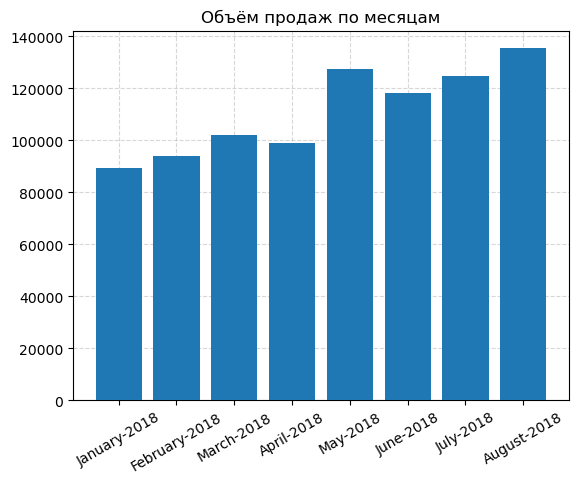

In [50]:
plt.bar(monthly_names, monthly_sales.values, zorder=3)
plt.title("Объём продаж по месяцам")
plt.xticks(rotation=30)
plt.grid(True, alpha=0.5, linestyle="--", zorder=0)
plt.show()

Опишите что вы видите на графике. Ваша задача - максимально описать график

C января по август 2018 года продажи выросли. Весь этот период наблюдается стабильный, хоть и с небольшими снижениями, рост показателей продаж.
Максимальный показатель выручки был в августе. В целом динамика продаж положительная и линейно вверх.

Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [11]:
df.describe()['Количество']

count    301355.000000
mean          2.951559
min           0.000000
25%           1.000000
50%           2.000000
75%           4.000000
max         200.000000
std           2.998154
Name: Количество, dtype: float64

In [12]:
df.loc[df['Количество'].idxmax()]

Дата            2018-06-28 00:00:00
Склад                             1
Контрагент              address_208
Номенклатура              product_0
Количество                      200
Name: 218822, dtype: object

Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [80]:
df["Месяц"] = df["Дата"].dt.month
df["День_недели"] = df["Дата"].dt.dayofweek

In [81]:
df.head()

,Дата,Склад,Контрагент,Номенклатура,Количество,Месяц,День_недели
0,2018-01-04,1,address_0,product_0,4,1,3
1,2018-01-04,1,address_0,product_1,4,1,3
2,2018-01-04,1,address_0,product_2,5,1,3
3,2018-01-04,1,address_0,product_3,10,1,3
4,2018-01-04,1,address_0,product_4,2,1,3


In [86]:
wednesdays_jja = df.query("Склад == 3 and Месяц in [6, 7, 8] and День_недели == 2")
wednesdays_jja.head()

,Дата,Склад,Контрагент,Номенклатура,Количество,Месяц,День_недели
191165,2018-06-06,3,address_206,product_0,2,6,2
191166,2018-06-06,3,address_206,product_1,4,6,2
191167,2018-06-06,3,address_206,product_2,4,6,2
191168,2018-06-06,3,address_206,product_3,2,6,2
191169,2018-06-06,3,address_206,product_4,1,6,2


In [89]:
top_product = wednesdays_jja.groupby("Номенклатура")["Количество"].sum().idxmax()
total_quantity = wednesdays_jja.groupby("Номенклатура")["Количество"].sum().max()

In [90]:
print(f"Топовый товар по продажам по средам за инюь, июль и август у склада 3: {top_product} которого продана {total_quantity}")

Топовый товар по продажам по средам за инюь, июль и август у склада 3: product_1 которого продана 2267


Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [94]:
weather_raw = pd.read_csv("weather.csv", sep=";", encoding="cp1251", skiprows=6, index_col=False)

In [115]:
weather_raw.head()

,Местное время в Астане,T,Po,P,Pa,U,DD,Ff,ff10,ff3,...,Cm,Ch,VV,Td,RRR,tR,E,Tg,E',sss
0,31.08.2018 23:00,8.2,736.6,768.3,0.2,78.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,4.6,Следы осадков,12.0,NaN,NaN,NaN,NaN
1,31.08.2018 20:00,9.6,736.4,767.9,1.2,88.0,"Ветер, дующий с западо-северо-запада",3,NaN,NaN,...,"Высококучевых, высокослоистых или слоисто-дожд...","Перистых, перисто-кучевых или перисто-слоистых...",NaN,7.7,Следы осадков,12.0,NaN,NaN,NaN,NaN
2,31.08.2018 17:00,11.3,735.2,766.4,0.4,83.0,"Ветер, дующий с востоко-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,8.5,NaN,NaN,NaN,NaN,NaN,NaN
3,31.08.2018 14:00,12.3,734.8,765.9,0.9,80.0,"Ветер, дующий с северо-востока",4,NaN,NaN,...,NaN,NaN,4.0,8.9,NaN,NaN,NaN,NaN,NaN,NaN
4,31.08.2018 11:00,13.2,733.9,764.8,1.0,83.0,"Ветер, дующий с северо-северо-востока",4,NaN,NaN,...,NaN,NaN,10.0,10.3,3.0,12.0,NaN,NaN,NaN,NaN


In [116]:
weather = weather_raw.iloc[:, 0:2]

In [117]:
weather.columns = ["Дата", "T"]
weather.columns

Index(['Дата', 'T'], dtype='object')

In [118]:
weather.dtypes

Дата     object
T       float64
dtype: object

In [126]:
weather["Дата"] = pd.to_datetime(weather["Дата"], dayfirst=True).dt.date
weather.dtypes

Дата     object
T       float64
dtype: object

In [127]:
weather.head()

,Дата,T
0,2018-08-31,8.2
1,2018-08-31,9.6
2,2018-08-31,11.3
3,2018-08-31,12.3
4,2018-08-31,13.2


In [134]:
daily_weather = weather.groupby("Дата")["T"].mean().reset_index()
daily_weather

,Дата,T
0,2018-01-01,-9.4625
1,2018-01-02,-9.5125
2,2018-01-03,-11.4625
3,2018-01-04,-14.0750
4,2018-01-05,-16.8625
...,...,...
238,2018-08-27,12.5250
239,2018-08-28,14.1125
240,2018-08-29,13.8250
241,2018-08-30,14.1750


In [135]:
daily_weather.dtypes

Дата     object
T       float64
dtype: object

In [138]:
daily_weather['Дата'] = pd.to_datetime(daily_weather['Дата'])
daily_weather.dtypes

Дата    datetime64[ns]
T              float64
dtype: object

In [139]:
merged_df = pd.merge(grouped_df, daily_weather, on="Дата", how="inner")
merged_df.head()

,Дата,Количество,T
0,2018-01-04,3734,-14.0750
1,2018-01-05,3643,-16.8625
2,2018-01-06,3193,-13.3000
3,2018-01-07,3298,-12.7500
4,2018-01-09,4055,-6.2500


In [145]:
temp_merged_df = merged_df.set_index("Дата")["T"].resample("ME").mean()
months = monthly_sales.index.strftime("%b")

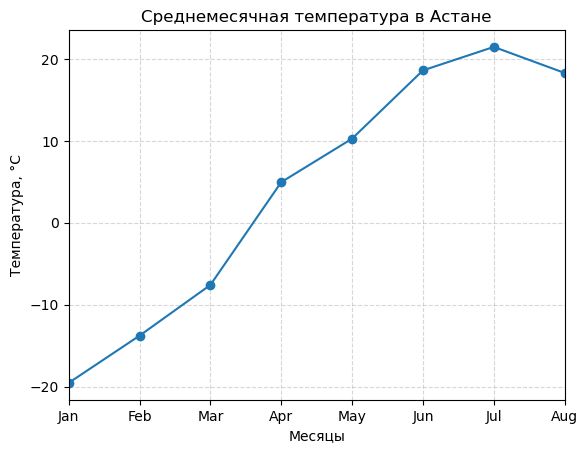

In [155]:
temp_merged_df.plot(kind="line", marker="o")
plt.xticks(ticks=temp_merged_df.index, labels=months[:len(temp_merged_df)])
plt.title('Среднемесячная температура в Астане')
plt.ylabel('Температура, °C')
plt.xlabel('Месяцы')
plt.grid(alpha=0.5, linestyle="--")
plt.show()

In [158]:
monthly_df = merged_df.resample("ME", on="Дата").agg({"T":"mean", 'Количество': 'sum'}).reset_index()
monthly_df["Месяц"] = monthly_df["Дата"].dt.strftime("%b")
monthly_df.head()

,Дата,T,Количество,Месяц
0,2018-01-31,-19.542188,89183,Jan
1,2018-02-28,-13.777604,93839,Feb
2,2018-03-31,-7.590385,102064,Mar
3,2018-04-30,4.954000,98833,Apr
4,2018-05-31,10.263889,127440,May


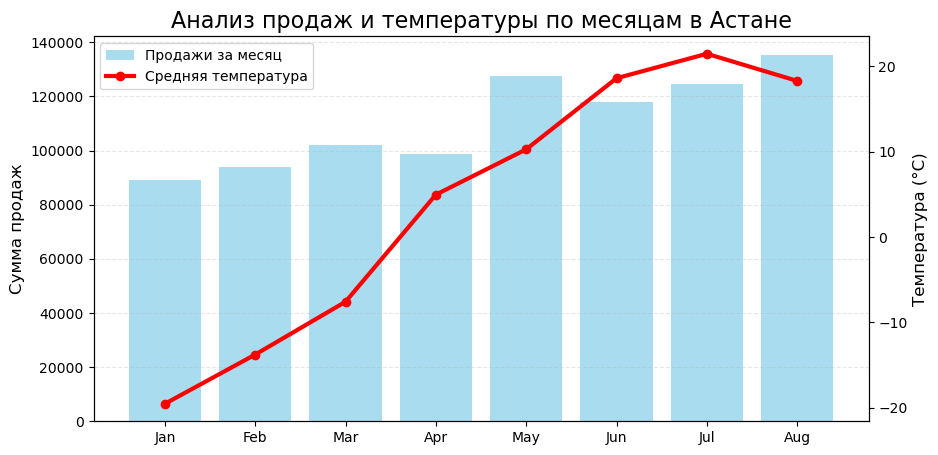

In [168]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.bar(monthly_df["Месяц"], monthly_df["Количество"], color="skyblue", alpha=0.7, label="Продажи за месяц")
ax1.set_ylabel("Сумма продаж", fontsize=12)

ax2 = ax1.twinx()
ax2.plot(monthly_df["Месяц"], monthly_df["T"], color="red", marker="o", linewidth=3, label="Средняя температура")
ax2.set_ylabel("Температура (°C)", fontsize=12)

plt.title("Анализ продаж и температуры по месяцам в Астане", fontsize=16)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="best")

plt.show()